# 01 - Data Exploration & Class Imbalance Analysis

This notebook explores the Credit Card Fraud Detection dataset to understand:
1. **How imbalanced the data is** (the core challenge)
2. **Feature distributions** by class (legitimate vs fraud)
3. **Data quality** (missing values, outliers)
4. **Why accuracy alone is misleading** for this problem

## The Central Problem

With 492 frauds out of 284,807 transactions (~0.17%), a "dumb" model that predicts everything as legitimate gets **99.83% accuracy** while catching **0% of fraud**. This is why we need different evaluation metrics!

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path so we can import our modules
sys.path.insert(0, str(Path.cwd().parent))

from src.data_loading import load_data, get_data_summary

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load Data

In [4]:
# Load the dataset
df = load_data('../data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -

## Step 2: Summary Statistics

In [5]:
summary = get_data_summary(df)

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
for key, value in summary.items():
    if key == 'fraud_ratio':
        print(f"{key:.<30} {value*100:.2f}%")
    else:
        print(f"{key:.<30} {value:,}")
print("="*60)


DATASET SUMMARY
total_transactions............ 284,807
total_features................ 31
missing_values................ 0
fraud_cases................... 492
legitimate_cases.............. 284,315
fraud_ratio................... 0.17%


## Step 3: Class Distribution - The Core Challenge


Class Distribution:
  Legitimate..... 284315 ( 99.83%)
  Fraud..........    492 (  0.17%)


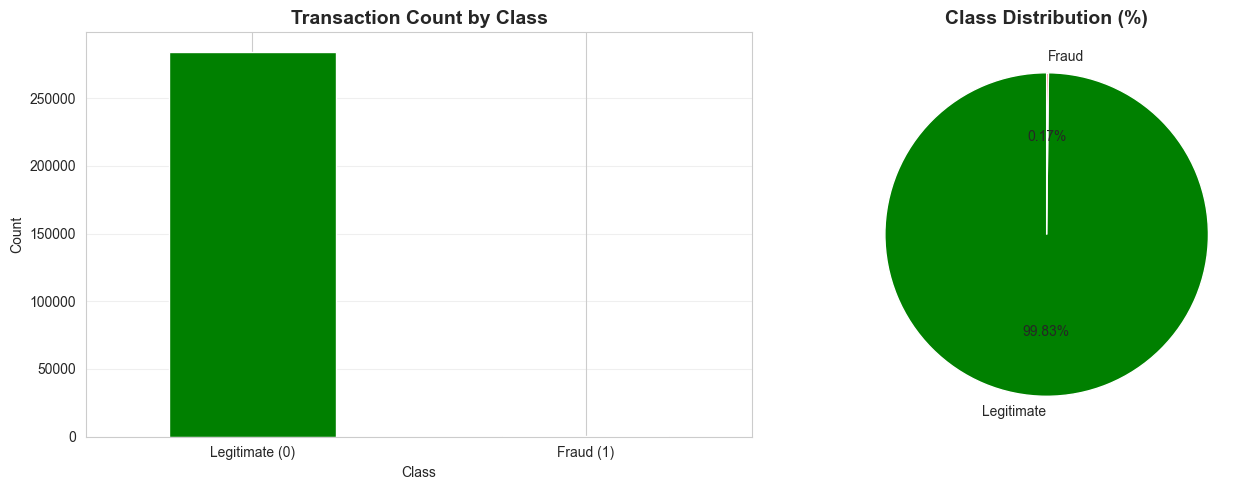


⚠️  KEY INSIGHT:
   A model that predicts everything as 'Legitimate' would achieve
   99.83% accuracy while catching 0% of fraud!


In [7]:
# Count classes
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print("\nClass Distribution:")
for class_label, count in class_counts.items():
    pct = class_percentages[class_label]
    label = 'Legitimate' if class_label == 0 else 'Fraud'
    print(f"  {label:.<15} {count:>6} ({pct:>6.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['green', 'red'], startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n⚠️  KEY INSIGHT:")
print(f"   A model that predicts everything as 'Legitimate' would achieve")
print(f"   {class_percentages[0]:.2f}% accuracy while catching 0% of fraud!")

## Step 4: Missing Values Check

In [8]:
missing = df.isnull().sum()

if missing.sum() == 0:
    print("✓ Good news: No missing values in the dataset!")
else:
    print("Missing values:")
    print(missing[missing > 0])

✓ Good news: No missing values in the dataset!


## Step 5: Feature Analysis - Amount and Time

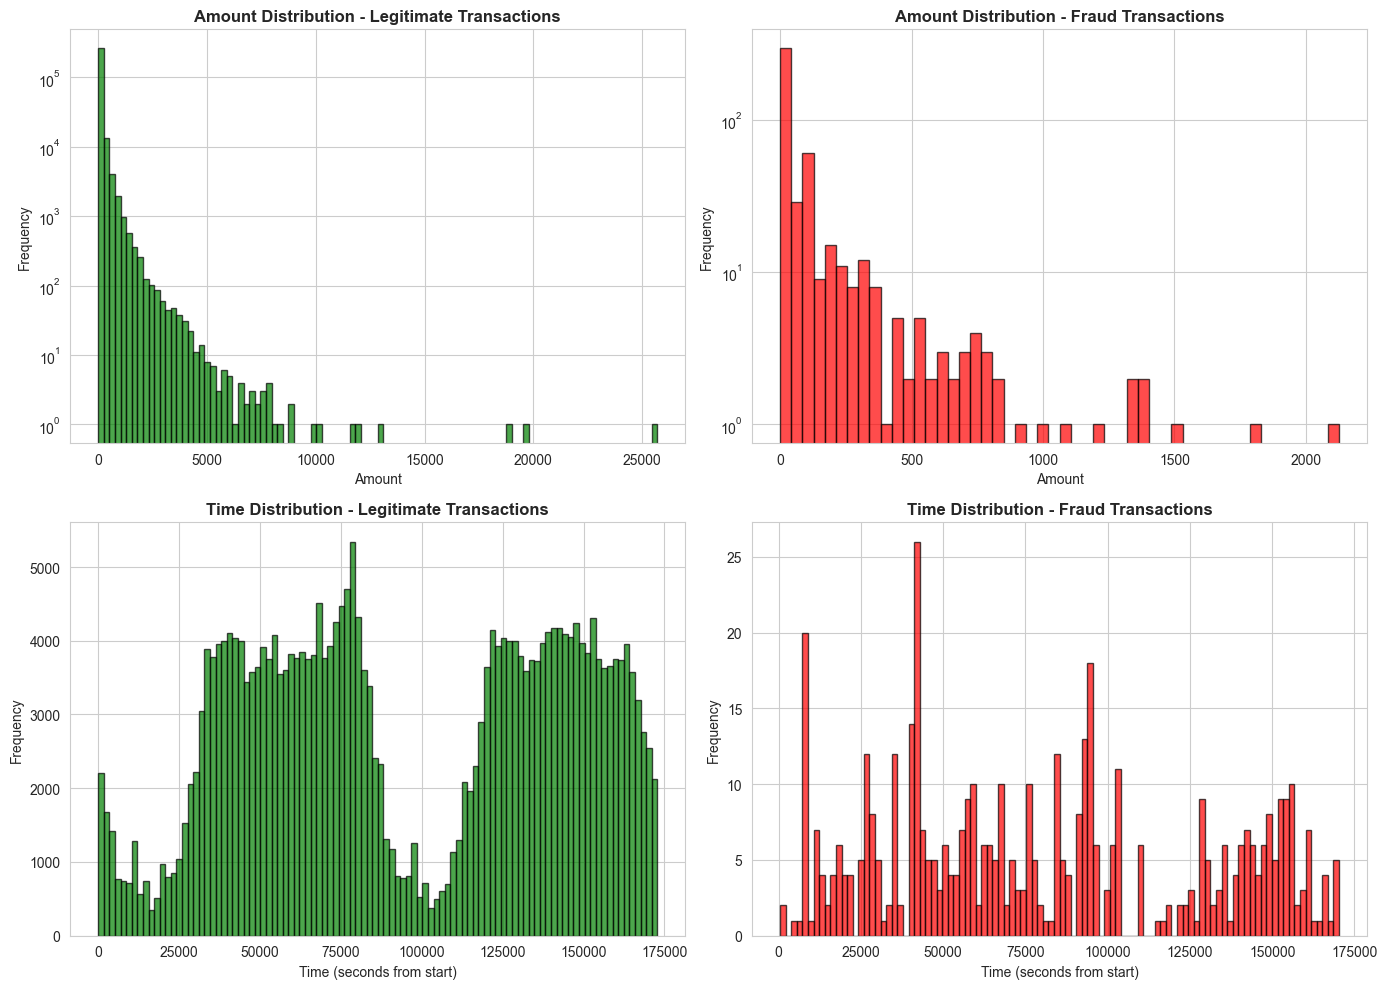


Amount Statistics:
  Legitimate - Mean: $88.29, Median: $22.00
  Fraud      - Mean: $122.21, Median: $9.25

Time Statistics:
  Legitimate - Mean: 94838s, Median: 84711s
  Fraud      - Mean: 80747s, Median: 75568s


In [9]:
# Separate by class
legitimate = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution - Legitimate
axes[0, 0].hist(legitimate['Amount'], bins=100, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Amount Distribution - Legitimate Transactions', fontweight='bold')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_yscale('log')

# Amount distribution - Fraud
axes[0, 1].hist(fraud['Amount'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Amount Distribution - Fraud Transactions', fontweight='bold')
axes[0, 1].set_xlabel('Amount')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yscale('log')

# Time distribution - Legitimate
axes[1, 0].hist(legitimate['Time'], bins=100, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Time Distribution - Legitimate Transactions', fontweight='bold')
axes[1, 0].set_xlabel('Time (seconds from start)')
axes[1, 0].set_ylabel('Frequency')

# Time distribution - Fraud
axes[1, 1].hist(fraud['Time'], bins=100, color='red', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Time Distribution - Fraud Transactions', fontweight='bold')
axes[1, 1].set_xlabel('Time (seconds from start)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/02_amount_time_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics
print("\nAmount Statistics:")
print(f"  Legitimate - Mean: ${legitimate['Amount'].mean():.2f}, Median: ${legitimate['Amount'].median():.2f}")
print(f"  Fraud      - Mean: ${fraud['Amount'].mean():.2f}, Median: ${fraud['Amount'].median():.2f}")

print("\nTime Statistics:")
print(f"  Legitimate - Mean: {legitimate['Time'].mean():.0f}s, Median: {legitimate['Time'].median():.0f}s")
print(f"  Fraud      - Mean: {fraud['Time'].mean():.0f}s, Median: {fraud['Time'].median():.0f}s")

## Step 6: PCA Features (V1-V28) Analysis


PCA Features: 28 components (V1 to V28)

⚠️  IMPORTANT:
   These V1-V28 features are Principal Component Analysis (PCA)
   transformations of the original features. They're anonymized for privacy.
   Therefore, we CANNOT interpret them as business variables.
   We can only use them for predictive modeling.


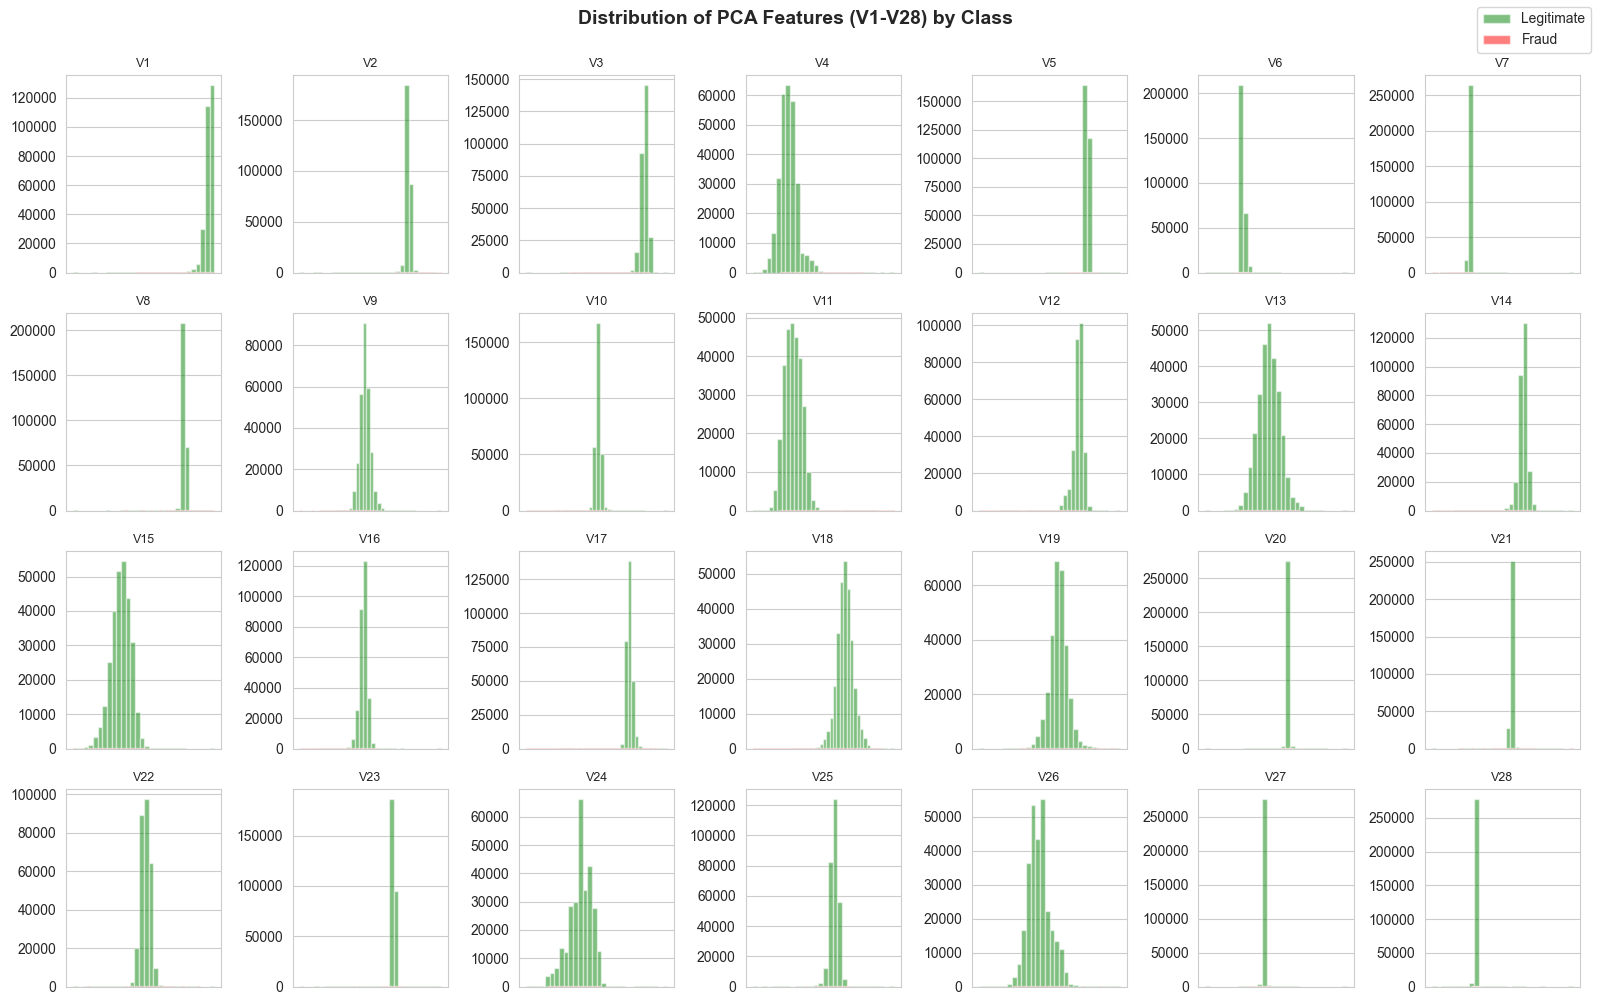

In [10]:
# V1-V28 are PCA-transformed features
pca_features = [col for col in df.columns if col.startswith('V')]

print(f"\nPCA Features: {len(pca_features)} components (V1 to V28)")
print("\n⚠️  IMPORTANT:")
print("   These V1-V28 features are Principal Component Analysis (PCA)")
print("   transformations of the original features. They're anonymized for privacy.")
print("   Therefore, we CANNOT interpret them as business variables.")
print("   We can only use them for predictive modeling.")

# Show that some features might have different distributions
fig, axes = plt.subplots(4, 7, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(pca_features[:28]):
    axes[idx].hist(legitimate[feature], bins=30, alpha=0.5, label='Legitimate', color='green')
    axes[idx].hist(fraud[feature], bins=30, alpha=0.5, label='Fraud', color='red')
    axes[idx].set_title(feature, fontsize=9)
    axes[idx].set_xticks([])

fig.legend(['Legitimate', 'Fraud'], loc='upper right')
plt.suptitle('Distribution of PCA Features (V1-V28) by Class', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/03_pca_features_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 7: Summary & Key Takeaways

In [11]:
print("\n" + "="*70)
print("KEY TAKEAWAYS - DATA EXPLORATION")
print("="*70)
print()
print("1️⃣  EXTREME CLASS IMBALANCE")
print(f"   Fraud cases: {summary['fraud_cases']:,} out of {summary['total_transactions']:,} ({summary['fraud_ratio']*100:.2f}%)")
print("   → Baseline model (predict all as legitimate): 99.83% accuracy, 0% recall on fraud!")
print()
print("2️⃣  NO MISSING VALUES")
print("   → Data quality is good, no need for imputation")
print()
print("3️⃣  PCA FEATURES LACK INTERPRETABILITY")
print("   → V1-V28 are anonymized, can't extract business rules")
print("   → Use only for modeling, not decision rules")
print()
print("4️⃣  AMOUNT & TIME DIFFERENCES")
print(f"   → Fraud amounts: Mean=${fraud['Amount'].mean():.2f}, Median=${fraud['Amount'].median():.2f}")
print(f"   → Legit amounts: Mean=${legitimate['Amount'].mean():.2f}, Median=${legitimate['Amount'].median():.2f}")
print("   → Fraud may occur at different times (analyze in next steps)")
print()
print("5️⃣  NEXT STEPS")
print("   → Preprocessing: Stratified split + scaling")
print("   → Baseline: Simple logistic regression (see the accuracy trap!)")
print("   → Balancing: class_weight vs SMOTE vs ensemble methods")
print("   → Evaluation: Focus on precision/recall/F1/PR-AUC, NOT accuracy")
print()
print("="*70)


KEY TAKEAWAYS - DATA EXPLORATION

1️⃣  EXTREME CLASS IMBALANCE
   Fraud cases: 492 out of 284,807 (0.17%)
   → Baseline model (predict all as legitimate): 99.83% accuracy, 0% recall on fraud!

2️⃣  NO MISSING VALUES
   → Data quality is good, no need for imputation

3️⃣  PCA FEATURES LACK INTERPRETABILITY
   → V1-V28 are anonymized, can't extract business rules
   → Use only for modeling, not decision rules

4️⃣  AMOUNT & TIME DIFFERENCES
   → Fraud amounts: Mean=$122.21, Median=$9.25
   → Legit amounts: Mean=$88.29, Median=$22.00
   → Fraud may occur at different times (analyze in next steps)

5️⃣  NEXT STEPS
   → Preprocessing: Stratified split + scaling
   → Baseline: Simple logistic regression (see the accuracy trap!)
   → Balancing: class_weight vs SMOTE vs ensemble methods
   → Evaluation: Focus on precision/recall/F1/PR-AUC, NOT accuracy

